Generating synthetic coordinates for Euclidean Metric parity...

          RUNNING REFERENCE FRAMEWORK (SciPy)
-> SciPy cdist finished.

          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy EuclideanMetric finished.

          PARITY VALIDATION
MSE on Euclidean Distance Matrix: 0.000000e+00

SUCCESS: DimRedPy EuclideanMetric perfectly matches SciPy reference.
Saved comparison plot to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_metrics\verify_parity_metrics_euclidean_plot.png


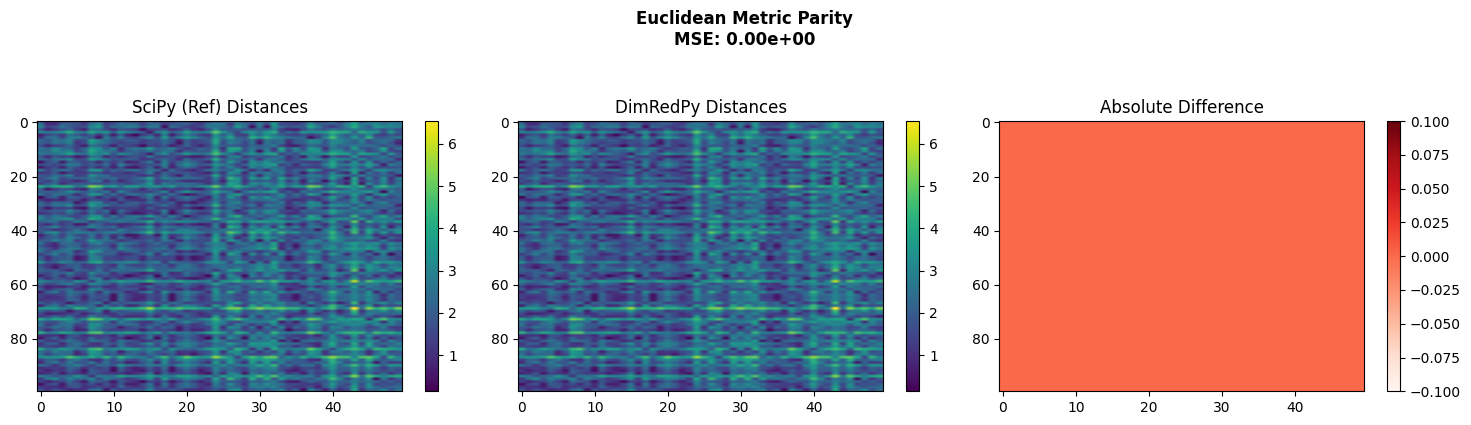

In [1]:
"""
Rigorous Verification of Metric Parity: Euclidean Metric
"""

import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from dimredpy.shared.metrics import EuclideanMetric

# ---------------------------------------------------------------------------
# 1. Generate Synthetic Data
# ---------------------------------------------------------------------------
print("Generating synthetic coordinates for Euclidean Metric parity...")
np.random.seed(42)
N = 100
M = 50
D = 3
X = np.random.randn(N, D)
Y = np.random.randn(M, D)

# ---------------------------------------------------------------------------
# 2. Run Reference Framework (SciPy)
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (SciPy)")
print("=======================================================")

ref_dist = cdist(X, Y, metric='euclidean')
print("-> SciPy cdist finished.")

# ---------------------------------------------------------------------------
# 3. Run DimRedPy Framework
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")

metric = EuclideanMetric()
dimred_dist = metric.pairwise_vec(X, Y)
print("-> DimRedPy EuclideanMetric finished.")

# ---------------------------------------------------------------------------
# 4. Parity Validation
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

mse = np.mean((ref_dist - dimred_dist) ** 2)
print(f"MSE on Euclidean Distance Matrix: {mse:.6e}")

if mse < 1e-10:
    print("\nSUCCESS: DimRedPy EuclideanMetric perfectly matches SciPy reference.")
else:
    print("\nFAILURE: Divergence detected in Euclidean Metric parity.")

# ---------------------------------------------------------------------------
# 5. Visual Verification
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='white')
fig.suptitle(f"Euclidean Metric Parity\nMSE: {mse:.2e}", fontweight='bold', y=1.05)

vmax = np.max(ref_dist)

im0 = axes[0].imshow(ref_dist, aspect='auto', cmap='viridis', vmax=vmax)
axes[0].set_title("SciPy (Ref) Distances")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(dimred_dist, aspect='auto', cmap='viridis', vmax=vmax)
axes[1].set_title("DimRedPy Distances")
fig.colorbar(im1, ax=axes[1])

diff = np.abs(ref_dist - dimred_dist)
im2 = axes[2].imshow(diff, aspect='auto', cmap='Reds')
axes[2].set_title("Absolute Difference")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plot_path = os.path.join(script_dir, "verify_parity_metrics_euclidean_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Saved comparison plot to {plot_path}")
